## Goal: Analyse monthly sales, top products, and regional performance.



In [ ]:
# pip install pandas matplotlib seaborn plotly
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load data
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')

# Monthly sales
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

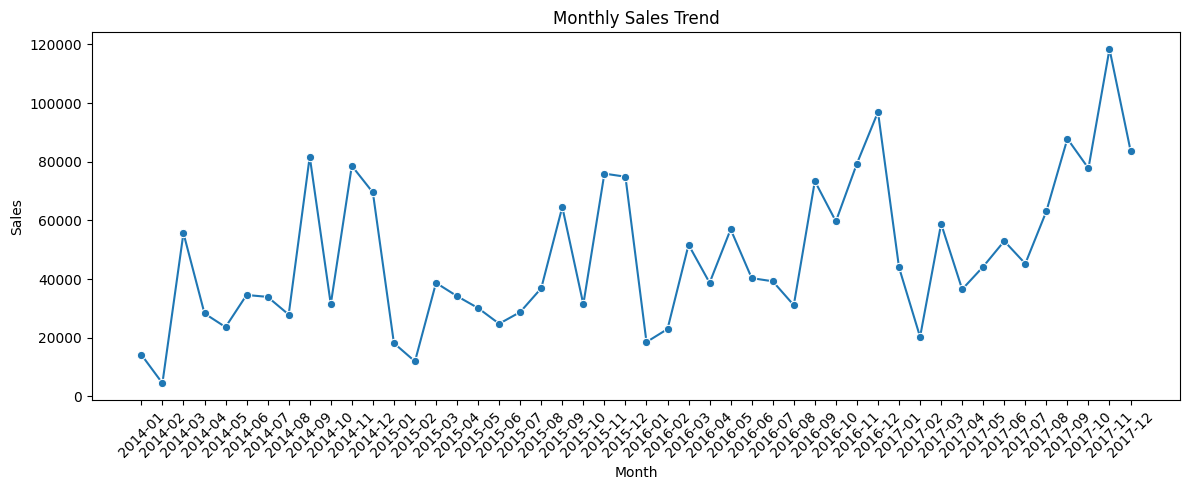

In [ ]:
# Plot 1: Monthly sales trend
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', marker='o')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_sales.png')
plt.show()

/tmp/ipykernel_4504/2910338230.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, y='Product Name', x='Sales', palette='viridis')


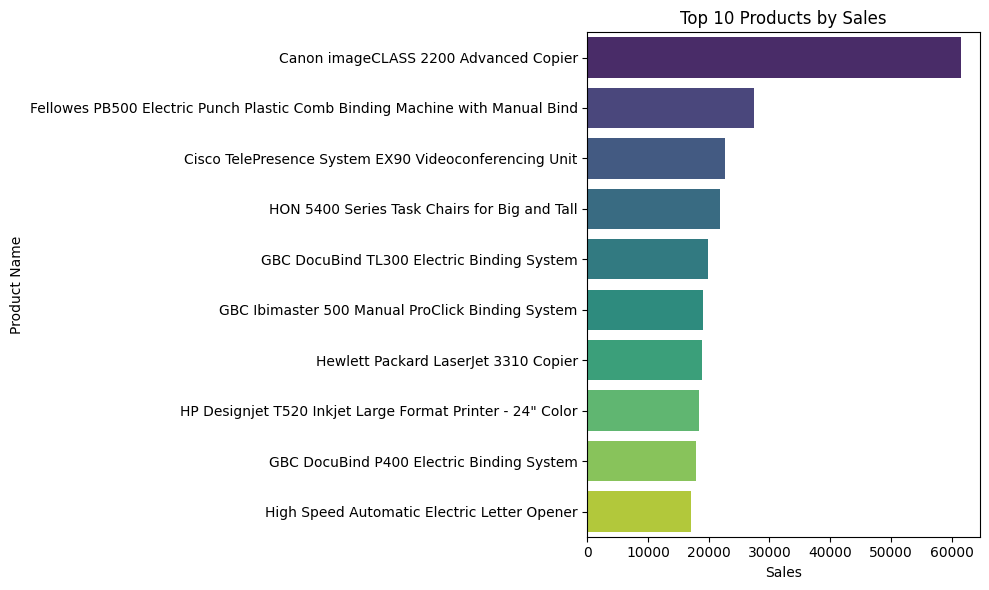

In [ ]:
# Top 10 products by sales
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=top_products, y='Product Name', x='Sales', palette='viridis')
plt.title('Top 10 Products by Sales')
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()

In [ ]:
# Interactive map: Sales by State
fig = px.choropleth(df.groupby('State')['Sales'].sum().reset_index(),
                    locations='State', locationmode='USA-states',
                    color='Sales', scope='usa',
                    title='Sales by State')
fig.write_html('sales_map.html')
fig.show()

print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Average Order Value: ${df.groupby('Order ID')['Sales'].sum().mean():,.2f}")

Total Sales: $2,297,200.86
Average Order Value: $458.61
